#ML4Net - Lab 1

## Team members

Melker Svensson (242994), Felipe Lopéz (266687), Raúl Martín (267819)

## Description

In this lab, you are going to get introduced into Multi-Armed Bandits (MABs) and Wi-Fi simulations. More specifically, you are going to implement a MAB algorithm that performs channel allocation in an Overlapping Basic Service Set (OBSS), i.e., in a scenario where multiple independent BSSs coexist.

## Instructions

*   Follow the steps from this Notebook and complete the proposed exercises.
*   Deliver the completed Notebook by uploading it to your Github repository.
*   Submission deadline: 8 May 2026 (EoB).

## Setting up the environment

1. Connect your Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


2. Download the Simulator's source code

In [ ]:
!wget https://github.com/fwilhelmi/fwilhelmi.github.io/raw/refs/heads/master/files/Komondor-lightweight.zip

--2026-04-27 14:32:49--  https://github.com/fwilhelmi/fwilhelmi.github.io/raw/refs/heads/master/files/Komondor-lightweight.zip
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/fwilhelmi/fwilhelmi.github.io/refs/heads/master/files/Komondor-lightweight.zip [following]
--2026-04-27 14:32:50--  https://raw.githubusercontent.com/fwilhelmi/fwilhelmi.github.io/refs/heads/master/files/Komondor-lightweight.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 979661 (957K) [application/zip]
Saving to: ‘Komondor-lightweight.zip’

Komondor-lightweigh 100%[===================>] 956.70K  --.-KB/s    in 0.05s   

3. Define the main path of the code

In [ ]:
!cd ./drive/MyDrive/AAX/Lab1

In [ ]:
mypath = "./"

4. Extract the source code

In [ ]:
!cp Komondor-lightweight.zip $mypath; cd $mypath; unzip Komondor-lightweight.zip

cp: 'Komondor-lightweight.zip' and './Komondor-lightweight.zip' are the same file
Archive:  Komondor-lightweight.zip
   creating: output/
  inflating: config_models           
  inflating: learning_modules/ml_model.h  
  inflating: main/traffic_generator.h  
  inflating: methods/auxiliary_methods.h  
  inflating: input/agents_monitoring.csv  
  inflating: input/input_nodes.csv   
  inflating: structures/action.h     
  inflating: main/compcxx_komondor_main.h  
  inflating: main/komondor_main.cc   
  inflating: main/build_local        
  inflating: structures/controller_report.h  
  inflating: structures/performance.h  
  inflating: methods/modulations_methods.h  
  inflating: structures/logger.h     
  inflating: structures/node_configuration.h  
  inflating: learning_modules/pre_processor.h  
  inflating: structures/logical_nack.h  
  inflating: list_of_macros.h        
  inflating: structures/notification.h  
  inflating: main/agent.h            
  inflating: structures/FIFO.h       

5. Give permissions to run the code

In [ ]:
!sudo apt-get install -y lib32stdc++6

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  lib32gcc-s1 libc6-i386
The following NEW packages will be installed:
  lib32gcc-s1 lib32stdc++6 libc6-i386
0 upgraded, 3 newly installed, 0 to remove and 2 not upgraded.
Need to get 3,640 kB of archives.
After this operation, 15.4 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 libc6-i386 amd64 2.35-0ubuntu3.13 [2,837 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 lib32gcc-s1 amd64 12.3.0-1ubuntu1~22.04.3 [63.9 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 lib32stdc++6 amd64 12.3.0-1ubuntu1~22.04.3 [739 kB]
Fetched 3,640 kB in 1s (2,932 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 

In [ ]:
!cd $mypath/; chmod -R 777 *

chmod: changing permissions of 'drive/.shortcut-targets-by-id': Operation not permitted
chmod: changing permissions of 'drive/.Encrypted': Input/output error
chmod: changing permissions of 'drive/.Encrypted/.shortcut-targets-by-id': Operation not permitted


6. Compile the code

In [ ]:
!cd $mypath/main; ./build_local

## How to run simulations

Komondor can be run by calling its compiled main file ("komondor_main") and indicating the value for different flags.

Next, you will see two different ways of running Komondor, depending on whether MAB Agents are instantiated or not.

In any case, **it is important to know** that:


*   Any input files used by the simulator will be located in the `/input` folder.
*   Any output files generated by the simulator will be located in the `/output` folder.

Apart from that, Komondor generates a set of console logs that give meaningful information.


### 1) Simulations without agents

To simulate specific scenarios (described using "input node" files) **without agents**, one must indicate the following flags:

In [ ]:
# DEFINE SIMULATION ARGUMENTS (NO AGENTS)

# Path of the file that describes the Wi-Fi nodes
INPUT_FILE_NODES='../input/input_nodes.csv'

# Path of the file where output logs are going to be written
OUTPUT_FILE_LOGS='../output/logs_test.txt'

# Path of the file where output logs are going to be written
SIMULATION_CODE='AAX-LAB1'

# Flag to indicate whether "NODE LOGS" will be written into output files (1) or not (0)
FLAG_SAVE_NODE_LOGS=1

# Flag to indicate whether "SYSTEM LOGS" will be printed in the console (1) or not (0)
FLAG_PRINT_SYSTEM_LOGS=1

# Flag to indicate whether "NODE LOGS" will be printed in the console (1) or not (0)
FLAG_PRINT_NODE_LOGS=1

# Total simulated time (in seconds)
SIM_TIME=100

# Value of the random seed that initializes the random number generator
SEED=7

In [ ]:
# RUN THE SIMULATION

!cd $mypath/main; ./komondor_main $INPUT_FILE_NODES $OUTPUT_FILE_LOGS $SIMULATION_CODE $FLAG_SAVE_NODE_LOGS $FLAG_PRINT_SYSTEM_LOGS $FLAG_PRINT_NODE_LOGS $SIM_TIME $SEED


*************************************************************************************
 KOMONDOR Wireless Network Simulator
 Copyright (C) 2017-2022, and GNU GPL'd, by Sergio Barrachina & Francesc Wilhelmi
  - GitHub repository: https://github.com/wn-upf/Komondor
*************************************************************************************


 FULL configuration entered per console (AGENTS DISABLED).
 Komondor input configuration:
  - nodes_input_filename: ../input/input_nodes.csv
  - agents_enabled: 0
  - script_output_filename: ../output/logs_test.txt
  - simulation_code: AAX-LAB1
  - save_node_logs: 1
  - print_system_logs: 1
  - print_node_logs: 1
  - sim_time: 100.000000 s
  - seed: 7

 Creating output files
  - Simulation output file 'output/logs_console_AAX-LAB1.txt' created!

 Reading system configuration file '../config_models'...
  - System environment properly set!

 Generating nodes DETERMINISTICALLY through NODES input file...
  - Reading nodes input file '../input/

### 2) Simulations with agents (used for keeping track of temporary performance)

To simulate specific scenarios (described using "input node" files) **with agents**, one must indicate the following flags:

In [ ]:
# DEFINE SIMULATION ARGUMENTS (WITH AGENTS FOR MONITORING PERFORMANCE)

# Path of the file that describes the Wi-Fi nodes
INPUT_FILE_NODES='../input/input_nodes.csv'

# Path of the file that describes the agents associated with nodes
INPUT_FILE_AGENTS='../input/agents_monitoring.csv'

# Path of the file where output logs are going to be written
OUTPUT_FILE_LOGS='../output/logs_test_agents.txt'

# Path of the file where output logs are going to be written
SIMULATION_CODE='AAX-LAB1-AGENTS'

# Flag to indicate whether "NODE LOGS" will be written into output files (1) or not (0)
FLAG_SAVE_NODE_LOGS=0

# Flag to indicate whether "AGENT LOGS" will be written into output files (1) or not (0)
FLAG_SAVE_AGENT_LOGS=0

# Flag to indicate whether "SYSTEM LOGS" will be printed in the console (1) or not (0)
FLAG_PRINT_SYSTEM_LOGS=1

# Flag to indicate whether "NODE LOGS" will be printed in the console (1) or not (0)
FLAG_PRINT_NODE_LOGS=1

# Flag to indicate whether "AGENT LOGS" will be printed in the console (1) or not (0)
FLAG_PRINT_AGENT_LOGS=1

# Total simulated time (in seconds)
SIM_TIME=100

# Value of the random seed that initializes the random number generator
SEED=7

Run the simulation

In [ ]:
!cd $mypath/main; ./komondor_main $INPUT_FILE_NODES $INPUT_FILE_AGENTS $OUTPUT_FILE_LOGS $SIMULATION_CODE $FLAG_SAVE_NODE_LOGS $FLAG_SAVE_AGENT_LOGS $FLAG_PRINT_SYSTEM_LOGS $FLAG_PRINT_NODE_LOGS $FLAG_PRINT_AGENT_LOGS $SIM_TIME $SEED


*************************************************************************************
 KOMONDOR Wireless Network Simulator
 Copyright (C) 2017-2022, and GNU GPL'd, by Sergio Barrachina & Francesc Wilhelmi
  - GitHub repository: https://github.com/wn-upf/Komondor
*************************************************************************************


 FULL configuration entered per console (AGENTS ENABLED).
 Komondor input configuration:
  - nodes_input_filename: ../input/input_nodes.csv
  - agents_enabled: 1
  - agents_input_filename: ../input/agents_monitoring.csv
  - script_output_filename: ../output/logs_test_agents.txt
  - simulation_code: AAX-LAB1-AGENTS
  - save_node_logs: 0
  - print_system_logs: 1
  - print_node_logs: 1
  - sim_time: 100.000000 s
  - seed: 7

 Creating output files
  - Simulation output file 'output/logs_console_AAX-LAB1-AGENTS.txt' created!

 Reading system configuration file '../config_models'...
  - System environment properly set!

 Generating nodes DETERMI

## EXERCISES

### Exercise 1:
Run the simulator (without agents) for the provided input nodes file (`/input/input_nodes.csv`). Before running the simulation, activate the flag that allows saving node logs into a file. After running the simulation, use the information from the log files of each node (e.g., AP_A, STA_A1, AP_B, STA_B1) to plot the scenario. To make the plot, consider the position of the nodes, the channel used, and the power strength that each node perceives from each other node in the deployment.

*Note: To know the power strength perceived by a given device (e.g., AP A) from any other devices (e.g., STA A1, AP B, STA B1), check the logs of that node and identify the cases where other nodes are detected to start/stop a transmission.*

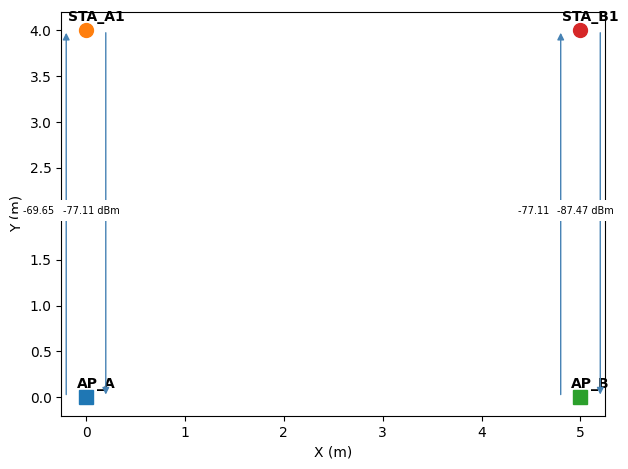

In [ ]:
# (response to exercise 1)
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")

# Nodes: name -> (x, y)
nodes = {"AP_A": (0,0), "STA_A1": (0,4), "AP_B": (5,0), "STA_B1": (5,4)}

for name, (x, y) in nodes.items():
    marker = "s" if "AP" in name else "o"
    ax.plot(x, y, marker=marker, ms=10)
    ax.text(x + 0.1, y + 0.1, name, ha='center', fontweight='bold')

# (x0,y0) -> (x1,y1), rssi, x offset to separate the two arrows
links = [
    (0, 0, 0, 4, -69.65, -0.2),
    (0, 4, 0, 0, -77.11,  0.2),
    (5, 0, 5, 4, -77.11, -0.2),
    (5, 4, 5, 0, -87.47,  0.2),
]

for x0, y0, x1, y1, rssi, dx in links:
    ax.annotate("", xy=(x1+dx, y1), xytext=(x0+dx, y0),
                arrowprops=dict(arrowstyle="-|>", color="steelblue"))
    ax.text(x0+dx - 0.15, (y0+y1)/2, f"{rssi} dBm", fontsize=7, ha='center',
            bbox=dict(fc='white', ec='none'))

plt.tight_layout()
plt.show()

### Exercise 2:

Run the simulator (this time, with agents in "monitor" mode) for the provided input nodes file (`/input/input_nodes.csv`). The input agents file to be used is provided as (`/input/agents_monitoring.csv`). Ensure that the agent logs are saved into files by setting the corresponding flag to 1. After running the simulation, use the agent log files to plot the temporary throughput obtained by each AP.

In [ ]:
# (response to exercise 2)
# DEFINE SIMULATION ARGUMENTS (WITH AGENTS FOR MONITORING PERFORMANCE)

# Path of the file that describes the Wi-Fi nodes
INPUT_FILE_NODES='../input/input_nodes.csv'

# Path of the file that describes the agents associated with nodes
INPUT_FILE_AGENTS='../input/agents_monitoring.csv'

# Path of the file where output logs are going to be written
OUTPUT_FILE_LOGS='../output/logs_test_agents.txt'

# Path of the file where output logs are going to be written
SIMULATION_CODE='AAX-LAB1-AGENTS'

# Flag to indicate whether "NODE LOGS" will be written into output files (1) or not (0)
FLAG_SAVE_NODE_LOGS=0

# Flag to indicate whether "AGENT LOGS" will be written into output files (1) or not (0)
FLAG_SAVE_AGENT_LOGS=1

# Flag to indicate whether "SYSTEM LOGS" will be printed in the console (1) or not (0)
FLAG_PRINT_SYSTEM_LOGS=1

# Flag to indicate whether "NODE LOGS" will be printed in the console (1) or not (0)
FLAG_PRINT_NODE_LOGS=1

# Flag to indicate whether "AGENT LOGS" will be printed in the console (1) or not (0)
FLAG_PRINT_AGENT_LOGS=1

# Total simulated time (in seconds)
SIM_TIME=100

# Value of the random seed that initializes the random number generator
SEED=7

In [ ]:
!cd $mypath/main; ./komondor_main $INPUT_FILE_NODES $INPUT_FILE_AGENTS $OUTPUT_FILE_LOGS $SIMULATION_CODE $FLAG_SAVE_NODE_LOGS $FLAG_SAVE_AGENT_LOGS $FLAG_PRINT_SYSTEM_LOGS $FLAG_PRINT_NODE_LOGS $FLAG_PRINT_AGENT_LOGS $SIM_TIME $SEED


*************************************************************************************
 KOMONDOR Wireless Network Simulator
 Copyright (C) 2017-2022, and GNU GPL'd, by Sergio Barrachina & Francesc Wilhelmi
  - GitHub repository: https://github.com/wn-upf/Komondor
*************************************************************************************


 FULL configuration entered per console (AGENTS ENABLED).
 Komondor input configuration:
  - nodes_input_filename: ../input/input_nodes.csv
  - agents_enabled: 1
  - agents_input_filename: ../input/agents_monitoring.csv
  - script_output_filename: ../output/logs_test_agents.txt
  - simulation_code: AAX-LAB1-AGENTS
  - save_node_logs: 0
  - print_system_logs: 1
  - print_node_logs: 1
  - sim_time: 100.000000 s
  - seed: 7

 Creating output files
  - Simulation output file 'output/logs_console_AAX-LAB1-AGENTS.txt' created!

 Reading system configuration file '../config_models'...
  - System environment properly set!

 Generating nodes DETERMI

In [ ]:

def extract_throughput(file_path):
    values = []
    with open(file_path, 'r') as file:
        for line in file:
            if "throughput" in line:
                parts = line.strip().split()
                # Example: ["throughput", "=", "123.45"]
                try:
                    idx = parts.index("=")
                    values.append(float(parts[idx + 1]))
                except (ValueError, IndexError):
                    pass  # skip malformed lines
    return values

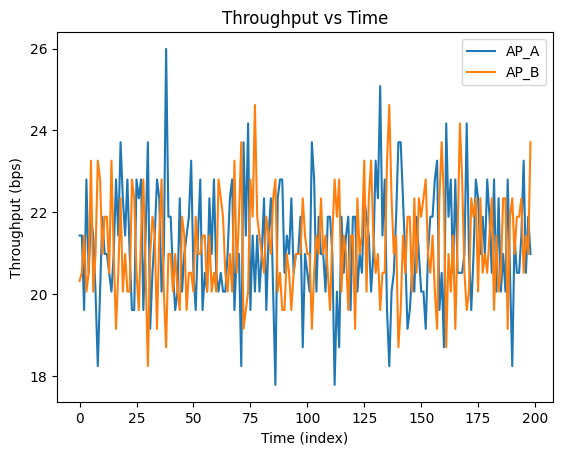

In [ ]:
import matplotlib.pyplot as plt

file_path_A = "/content/output/logs_output_AAX-LAB1-AGENTS_A0_A.txt"
file_path_B = "/content/output/logs_output_AAX-LAB1-AGENTS_A1_B.txt"

array_A = extract_throughput(file_path_A)
array_B = extract_throughput(file_path_B)

plt.plot(array_A, label='AP_A')
plt.plot(array_B, label='AP_B')

plt.xlabel('Time (index)')
plt.ylabel('Throughput (bps)')
plt.title('Throughput vs Time')
plt.legend()
plt.show()

### Exercise 3:

Copy the `agents_monitoring.csv` file, rename it as `agents_egreedy.csv`, and modify it as follows:
- Indicate the possible "channel actions" by indicating `0,1` in the column 'actions channels' of each agent.
- Set the colum "learning mechanism" to `1`(which stands for multi-armed bandits) for each agent.
- Set the column "selected strategy" to `1` (which stands for ɛ-greedy) for each agent.

Then, run the simulation using `agents_egreedy.csv` and plot the temporary throughput obtained by each AP, as done in Exercise 2. In addition, read the console logs from Komondor and explain the displayed agent logs.

**Important:** In case of experiencing a run-time error, check that the fields in the 'agents' file are separated by a semicolon (`;`).

In [ ]:
# (response to exercise 3)
# DEFINE SIMULATION ARGUMENTS (WITH AGENTS FOR MONITORING PERFORMANCE)

# Path of the file that describes the Wi-Fi nodes
INPUT_FILE_NODES='/content/input/input_nodes.csv'

# Path of the file that describes the agents associated with nodes
INPUT_FILE_AGENTS='/content/drive/MyDrive/AAX/Lab1/input/agents_egreedy.csv'

# Path of the file where output logs are going to be written
OUTPUT_FILE_LOGS='/content/output/logs_test_agents.txt'

# Path of the file where output logs are going to be written
SIMULATION_CODE='AAX-LAB1-AGENTS'

# Flag to indicate whether "NODE LOGS" will be written into output files (1) or not (0)
FLAG_SAVE_NODE_LOGS=0

# Flag to indicate whether "AGENT LOGS" will be written into output files (1) or not (0)
FLAG_SAVE_AGENT_LOGS=1

# Flag to indicate whether "SYSTEM LOGS" will be printed in the console (1) or not (0)
FLAG_PRINT_SYSTEM_LOGS=1

# Flag to indicate whether "NODE LOGS" will be printed in the console (1) or not (0)
FLAG_PRINT_NODE_LOGS=1

# Flag to indicate whether "AGENT LOGS" will be printed in the console (1) or not (0)
FLAG_PRINT_AGENT_LOGS=1

# Total simulated time (in seconds)
SIM_TIME=100

# Value of the random seed that initializes the random number generator
SEED=7

In [ ]:
!cd $mypath/main; ./komondor_main $INPUT_FILE_NODES $INPUT_FILE_AGENTS $OUTPUT_FILE_LOGS $SIMULATION_CODE $FLAG_SAVE_NODE_LOGS $FLAG_SAVE_AGENT_LOGS $FLAG_PRINT_SYSTEM_LOGS $FLAG_PRINT_NODE_LOGS $FLAG_PRINT_AGENT_LOGS $SIM_TIME $SEED


*************************************************************************************
 KOMONDOR Wireless Network Simulator
 Copyright (C) 2017-2022, and GNU GPL'd, by Sergio Barrachina & Francesc Wilhelmi
  - GitHub repository: https://github.com/wn-upf/Komondor
*************************************************************************************


 FULL configuration entered per console (AGENTS ENABLED).
 Komondor input configuration:
  - nodes_input_filename: /content/input/input_nodes.csv
  - agents_enabled: 1
  - agents_input_filename: /content/drive/MyDrive/AAX/Lab1/input/agents_egreedy.csv
  - script_output_filename: /content/output/logs_test_agents.txt
  - simulation_code: AAX-LAB1-AGENTS
  - save_node_logs: 0
  - print_system_logs: 1
  - print_node_logs: 1
  - sim_time: 100.000000 s
  - seed: 7

 Creating output files
  - Simulation output file 'output/logs_console_AAX-LAB1-AGENTS.txt' created!

 Reading system configuration file '../config_models'...
  - System environment pr

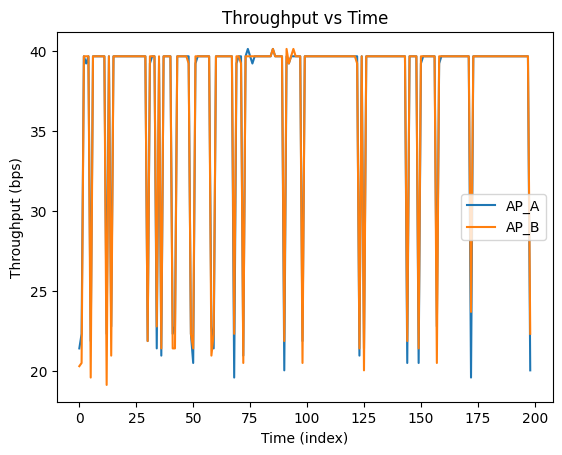

Average throughput of AP A: 37.363015075376886
Average throughput of AP B: 37.364120603015074


In [ ]:
array_A = extract_throughput(file_path_A)
array_B = extract_throughput(file_path_B)

plt.plot(array_A, label='AP_A')
plt.plot(array_B, label='AP_B')

plt.xlabel('Time (index)')
plt.ylabel('Throughput (bps)')
plt.title('Throughput vs Time')
plt.legend()
plt.show()

# Now we print the average throughput

print("Average throughput of AP A: " + str(sum(array_A)/len(array_A)))
print("Average throughput of AP B: " + str(sum(array_B)/len(array_B)))

From line 47 in the logs we have the following.

Agent A:

1.500000000000000;A0;C03;  - Action (0):
1.500000000000000;A0;C03;    · channel = 0
1.500000000000000;A0;C03;    · cca = -82.000000 dBm
1.500000000000000;A0;C03;    · tx_power = 15.000000 dBm
1.500000000000000;A0;C03;    · max_bandwidth = 1
1.500000000000000;A0;C03;  - Performance:
1.500000000000000;A0;C03;    · Average throughput = 39.67 Mbps

Agent B:

1.505000000000000;A1;C03;  - Action (1):
1.505000000000000;A1;C03;    · channel = 1
1.505000000000000;A1;C03;    · cca = -82.000000 dBm
1.505000000000000;A1;C03;    · tx_power = 15.000000 dBm
1.505000000000000;A1;C03;    · max_bandwidth = 1
1.505000000000000;A1;C03;  - Performance:
1.505000000000000;A1;C03;    · Average throughput = 39.67 Mbps

We exactly see what we expected, after sometime one of the agents picks a different channel from the other one resulting in each having unique access and usage of this channel. This  drastically improves on throughput.

### Exercise 4:
Create another input agents file (name it `agents_ml4net.csv`), but this time set the column "selected_strategy" (the last one) to 5.

The mechanism (as it is currently implemented) will just select actions randomly. For that reason, you have to define your own action-selection strategy by completing the code in `/learning_modules/network_optimization_methods/multi_armed_bandits.h`. More specifically, you will have to complete the function `PickArmML4Net()`, which contains all the logic. You can get inspiration from the other implemented MAB algorithms (e.g., UCB, Thompson sampling).

**IMPORTANT:** If you modify the source code, you will have to re-compile it (see step 6 in "Setting up the environment") before running new simulations.

In [ ]:
# (response to exercise 4)
# DEFINE SIMULATION ARGUMENTS (WITH AGENTS FOR MONITORING PERFORMANCE)

# Path of the file that describes the Wi-Fi nodes
INPUT_FILE_NODES='/content/input/input_nodes.csv'

# Path of the file that describes the agents associated with nodes
INPUT_FILE_AGENTS='/content/drive/MyDrive/AAX/Lab1/input/agents_ml4net.csv'

# Path of the file where output logs are going to be written
OUTPUT_FILE_LOGS='/content/output/logs_test_agents.txt'

# Path of the file where output logs are going to be written
SIMULATION_CODE='AAX-LAB1-AGENTS'

# Flag to indicate whether "NODE LOGS" will be written into output files (1) or not (0)
FLAG_SAVE_NODE_LOGS=0

# Flag to indicate whether "AGENT LOGS" will be written into output files (1) or not (0)
FLAG_SAVE_AGENT_LOGS=1

# Flag to indicate whether "SYSTEM LOGS" will be printed in the console (1) or not (0)
FLAG_PRINT_SYSTEM_LOGS=1

# Flag to indicate whether "NODE LOGS" will be printed in the console (1) or not (0)
FLAG_PRINT_NODE_LOGS=1

# Flag to indicate whether "AGENT LOGS" will be printed in the console (1) or not (0)
FLAG_PRINT_AGENT_LOGS=1

# Total simulated time (in seconds)
SIM_TIME=100

# Value of the random seed that initializes the random number generator
SEED=7

In [ ]:
!cd $mypath/main; ./build_local

In [ ]:
!cd $mypath/main; ./komondor_main $INPUT_FILE_NODES $INPUT_FILE_AGENTS $OUTPUT_FILE_LOGS $SIMULATION_CODE $FLAG_SAVE_NODE_LOGS $FLAG_SAVE_AGENT_LOGS $FLAG_PRINT_SYSTEM_LOGS $FLAG_PRINT_NODE_LOGS $FLAG_PRINT_AGENT_LOGS $SIM_TIME $SEED


*************************************************************************************
 KOMONDOR Wireless Network Simulator
 Copyright (C) 2017-2022, and GNU GPL'd, by Sergio Barrachina & Francesc Wilhelmi
  - GitHub repository: https://github.com/wn-upf/Komondor
*************************************************************************************


 FULL configuration entered per console (AGENTS ENABLED).
 Komondor input configuration:
  - nodes_input_filename: /content/input/input_nodes.csv
  - agents_enabled: 1
  - agents_input_filename: /content/drive/MyDrive/AAX/Lab1/input/agents_ml4net.csv
  - script_output_filename: /content/output/logs_test_agents.txt
  - simulation_code: AAX-LAB1-AGENTS
  - save_node_logs: 0
  - print_system_logs: 1
  - print_node_logs: 1
  - sim_time: 100.000000 s
  - seed: 7

 Creating output files
  - Simulation output file 'output/logs_console_AAX-LAB1-AGENTS.txt' created!

 Reading system configuration file '../config_models'...
  - System environment pro

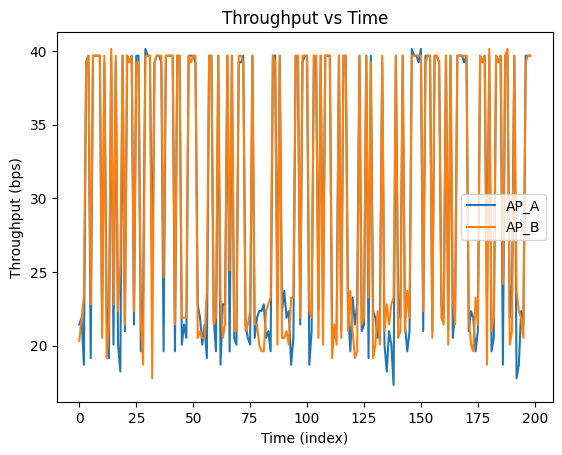

Average throughput of AP A: 29.896331658291455
Average throughput of AP B: 30.12894472361809


In [ ]:
# Random channel access

array_A = extract_throughput(file_path_A)
array_B = extract_throughput(file_path_B)

plt.plot(array_A, label='AP_A')
plt.plot(array_B, label='AP_B')

plt.xlabel('Time (index)')
plt.ylabel('Throughput (bps)')
plt.title('Throughput vs Time')
plt.legend()
plt.show()

# Now we print the average throughput

print("Average throughput of AP A: " + str(sum(array_A)/len(array_A)))
print("Average throughput of AP B: " + str(sum(array_B)/len(array_B)))

### Exercise 5:

Run a simulation to test your action-selection strategy. Compare it to ɛ-greedy (Exercise 3) by plotting the temporary throughput obtained by each of the mechanisms.

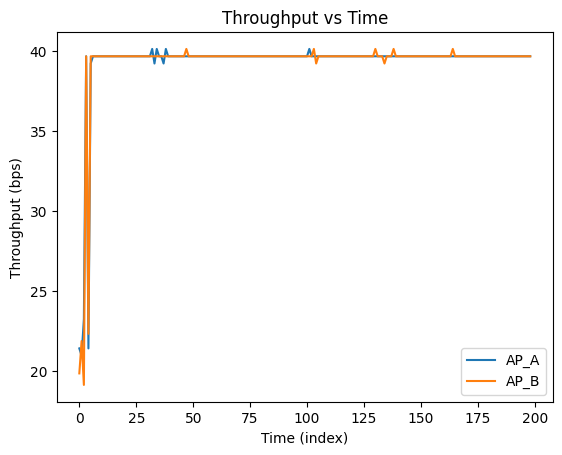

Average throughput of AP A: 39.31276381909548
Average throughput of AP B: 39.29798994974875


In [ ]:
file_path_A = "/content/output/logs_output_AAX-LAB1-AGENTS_A0_A.txt"
file_path_B = "/content/output/logs_output_AAX-LAB1-AGENTS_A1_B.txt"
array_A = extract_throughput(file_path_A)
array_B = extract_throughput(file_path_B)

plt.plot(array_A, label='AP_A')
plt.plot(array_B, label='AP_B')

plt.xlabel('Time (index)')
plt.ylabel('Throughput (bps)')
plt.title('Throughput vs Time')
plt.legend()
plt.show()

# Now we print the average throughput

print("Average throughput of AP A: " + str(sum(array_A)/len(array_A)))
print("Average throughput of AP B: " + str(sum(array_B)/len(array_B)))

Our approach:

Each agent mostly sticks to what it knows, but occasionally one agent gets designated as the "explorer" based on its ID and the current random number. This is suposed to happen in such a way that its only this agent that explores and no other (thus unique access to the new channel). The explorer tries each arm it hasn't tested yet, one at a time in order, until every arm has been sampled at least once. After that, all exploration stops and every agent permanently locks onto whichever arm gave the highest reward, but only if it's more than 20% better than what they're currently on, to avoid switching for noise.

=> refrence code at the end of notebook

Results:

This approach has the best average throughput out of all the runs. The one performing worst is of course where both agents keep to the same channel and do not change (first run). The second worst is the random one, where they compete regularly for the same channel.

Epsilon-greedy performs really well; only occasionally do the agents explore, and otherwise they keep to the best one so far.

Our strategy performs the best under this context, but would not generalize well on other tasks. We know that unique access to each channel is optimal so we have this in mind for the algorithm.

### Exercise 6:

Now, modify the "input_nodes.csv" and the input agent files (`agents_egreedy.csv` and `agents_ml4net.csv`) to add a third BSS, which must use the same configuration as the other BSSs but whose AP and STA must be placed at (10,0,0) m and (10,4,0) m, respectively. In the agents file, you will also have to add a third column so that the third BSS gets an agent enrolled.

Run N=5 simulations (using different random seeds) for each action-selection strategy and plot the average throughput obtained by each BSS across the different simulations for each approach.



In [ ]:
!cd $mypath/main; ./build_local

In [ ]:
INPUT_FILE_NODES = '/content/input/input_nodes.csv'
OUTPUT_FILE_LOGS = '/content/output/logs_test_agents.txt'

STRATEGIES = {
    'egreedy': '/content/drive/MyDrive/AAX/Lab1/input/agents_egreedy.csv',
    'ml4net':  '/content/drive/MyDrive/AAX/Lab1/input/agents_ml4net.csv',
}

N_SIMULATIONS = 5
SEEDS = [7, 42, 123, 256, 999]   # one per simulation run
SIM_TIME = 100

FLAG_SAVE_NODE_LOGS    = 0
FLAG_SAVE_AGENT_LOGS   = 1
FLAG_PRINT_SYSTEM_LOGS = 0
FLAG_PRINT_NODE_LOGS   = 0
FLAG_PRINT_AGENT_LOGS  = 0

BSSS = ['A', 'B', 'C']   # one entry per BSS

def get_log_path(strategy_name, seed):
    return f'/content/output/logs_{strategy_name}_seed{seed}.txt'

def get_agent_log_path(strategy_name, seed, agent_id, bss_code):
    sim_code = f'AAX-LAB1-{strategy_name.upper()}-seed{seed}'
    return f'/content/output/logs_output_{sim_code}_A{agent_id}_{bss_code}.txt'

results = {strategy: {bss: [] for bss in BSSS} for strategy in STRATEGIES}
for strategy_name, input_file_agents in STRATEGIES.items():
    print(f"\n{'='*55}")
    print(f"  Strategy: {strategy_name}")
    print(f"{'='*55}")
    for i, seed in enumerate(SEEDS):
        sim_code = f'AAX-LAB1-{strategy_name.upper()}-seed{seed}'
        output_log = get_log_path(strategy_name, seed)
        print(f"  [{i+1}/{N_SIMULATIONS}] Running seed={seed}  (sim_code={sim_code})")
        # Run the simulator
        !cd $mypath/main; ./komondor_main \
            $INPUT_FILE_NODES \
            $input_file_agents \
            $output_log \
            $sim_code \
            $FLAG_SAVE_NODE_LOGS \
            $FLAG_SAVE_AGENT_LOGS \
            $FLAG_PRINT_SYSTEM_LOGS \
            $FLAG_PRINT_NODE_LOGS \
            $FLAG_PRINT_AGENT_LOGS \
            $SIM_TIME \
            $seed

        # Extract average throughput for each run
        for agent_id, bss_code in enumerate(BSSS):
            file_path = get_agent_log_path(strategy_name, seed, agent_id, bss_code)
            array = extract_throughput(file_path)
            avg   = sum(array) / len(array) if array else 0.0
            results[strategy_name][bss_code].append(avg)






  Strategy: egreedy
  [1/5] Running seed=7  (sim_code=AAX-LAB1-EGREEDY-seed7)

*************************************************************************************
 KOMONDOR Wireless Network Simulator
 Copyright (C) 2017-2022, and GNU GPL'd, by Sergio Barrachina & Francesc Wilhelmi
  - GitHub repository: https://github.com/wn-upf/Komondor
*************************************************************************************


------------------------------------------
 SIMULATION 'AAX-LAB1-EGREEDY-seed7' STARTED
* 0 % *
* 5 % *
* 10 % *
* 15 % *
* 20 % *
* 25 % *
* 30 % *
* 35 % *
* 40 % *
* 45 % *
* 50 % *
* 55 % *
* 60 % *
* 65 % *
* 70 % *
* 75 % *
* 80 % *
* 85 % *
* 90 % *
* 95 % *
* 100 % *

 STOP KOMONDOR SIMULATION '' (seed 7) SIMULATION '' FINISHED
------------------------------------------
# -------------------------------------------------------------------------
# CostSimEng with SimpleQueue, stopped at 100.000000
# 507183 events processed in 2.050 seconds, event processin

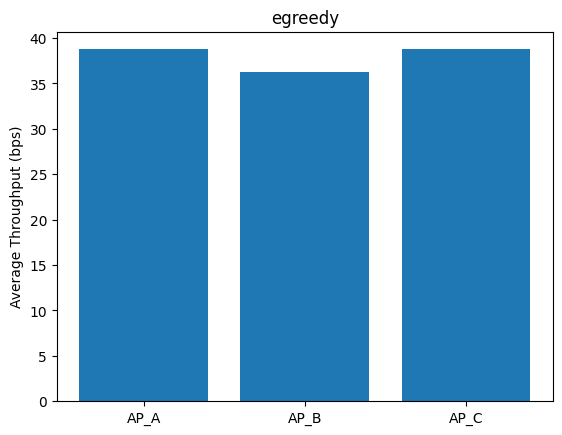

  AP_A: 38.75 bps
  AP_B: 36.30 bps
  AP_C: 38.73 bps


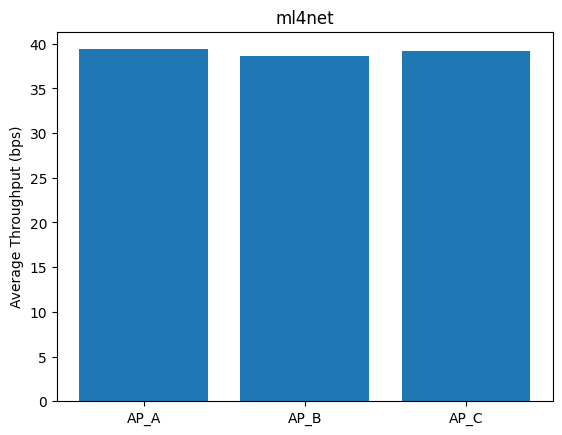

  AP_A: 39.37 bps
  AP_B: 38.61 bps
  AP_C: 39.23 bps


In [ ]:
import numpy as np
for strategy_name, bss_avgs in results.items():
    means = [np.mean(bss_avgs[bss]) for bss in BSSS]
    plt.figure()
    plt.bar([f'AP_{bss}' for bss in BSSS], means)
    plt.title(strategy_name)
    plt.ylabel('Average Throughput (bps)')
    plt.show()
    for bss, mean in zip(BSSS, means):
        print(f"  AP_{bss}: {mean:.2f} bps")

We can see again that our implementation outperforms epsilon greedy, but as mentioned before this is only for this very sepsific case, and it would not generalize well.

Refrence code for implementation of agents_ml4net:

int PickArmML4Net(int num_arms, int current_arm) {
  
            
            if (num_arms <= 1) return 0;

            // Find best known arm by max observed reward
            int    best_arm    = 0;
            double best_reward = reward_per_arm[0];
            for (int i = 1; i < num_arms; ++i) {
                if (reward_per_arm[i] > best_reward) {
                    best_reward = reward_per_arm[i];
                    best_arm    = i;
                }
            }

            // Find the next arm that has never been tested (sequential exploration)
            int next_untested = -1;
            for (int i = 0; i < num_arms; ++i) {
                if (times_arm_has_been_selected[i] == 0) {
                    next_untested = i;
                    break;
                }
            }

            // All arms tested: permanently exploit, only switch if >20% better
            if (next_untested == -1) {
                if (current_arm >= 0 &&
                    best_reward > reward_per_arm[current_arm] * 1.20)
                    return best_arm;
                return (current_arm >= 0) ? current_arm : best_arm;
            }

            // Still in exploration phase: jitter in [2,7] offsets the modulo
            // so agent_id=0 does not dominate when num_iterations is small.
            int  roundJitter = 2 + rand() % 6;
            bool isExplorer  = (num_iterations % (roundJitter + agent_id) == 0);

            if (!isExplorer) {
                if (current_arm >= 0 &&
                    best_reward > reward_per_arm[current_arm] * 1.20)
                    return best_arm;
                return (current_arm >= 0) ? current_arm : best_arm;
            }

            // Explorer: try the next untested arm in order
            return next_untested;
        }
